## Aula sobre Pré-Processamento

In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
#Média de compra por pessoa
df['compra_por_pessoa'] = df['total_bill'] / df['size']
#Relação da gorjeta por compra
df['porcentagem_gorjeta'] = df['tip'] / df['total_bill']
df.head()

,total_bill,tip,sex,smoker,day,time,size,compra_por_pessoa,porcentagem_gorjeta
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500,0.146808


In [7]:
#Transformação de variáveis categóricas
from sklearn.preprocessing import OrdinalEncoder
copia = df.copy()
#Nominal
df_encoder = pd.get_dummies(df, columns=['sex', 'smoker', 'time'], dtype=int, drop_first=True)
# df_encoder.head()

#Ordinal
ordinal = OrdinalEncoder(categories=[['Thur', 'Fri', 'Sat', 'Sun']], dtype=int)
df_encoder['day_encoder'] = ordinal.fit_transform(df[['day']])
df_encoder.drop('day', axis=1, inplace=True)
df_encoder.head()

# copia['day_encoder'] = df_encoder['day_encoder']
# copia.head(20)

,total_bill,tip,size,compra_por_pessoa,porcentagem_gorjeta,sex_Female,smoker_No,time_Dinner,day_encoder
0,16.99,1.01,2,8.495000,0.059447,1,1,1,3
1,10.34,1.66,3,3.446667,0.160542,0,1,1,3
2,21.01,3.50,3,7.003333,0.166587,0,1,1,3
3,23.68,3.31,2,11.840000,0.139780,0,1,1,3
4,24.59,3.61,4,6.147500,0.146808,1,1,1,3


1.1332130376158203
1.2184840156638836
ShapiroResult(statistic=0.9197187941346587, pvalue=3.324539186809284e-10)
A coluna "total_bill" não segue uma distribuição normal
1.2013819477935266
1.8235866685282769
ShapiroResult(statistic=0.9218612788596968, pvalue=4.939244244226715e-10)


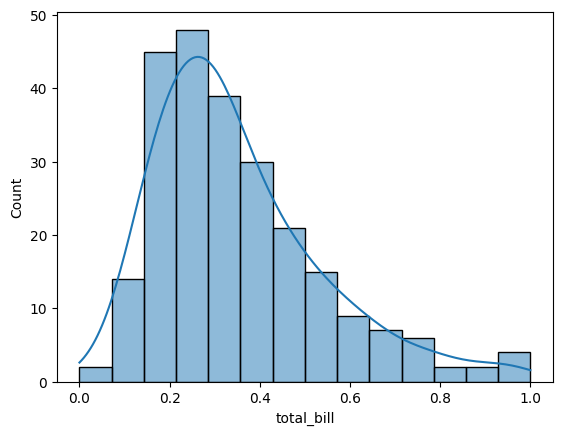

In [17]:
import matplotlib.pyplot as plt
from scipy import stats 
# Testar a normalidade das variáveis numéricas
print(df_encoder['total_bill'].skew())
print(df_encoder['total_bill'].kurt())
print(stats.shapiro(df_encoder['total_bill']))
print('A coluna "total_bill" não segue uma distribuição normal')
print(df_encoder['compra_por_pessoa'].skew())
print(df_encoder['compra_por_pessoa'].kurt())
print(stats.shapiro(df_encoder['compra_por_pessoa']))
print('A coluna "compra_por_pessoa" não segue uma distribuição normal')
sns.histplot(df_encoder['total_bill'], kde=True)
plt.show()


In [18]:
#Transformação de variáveis numéricas

from sklearn.preprocessing import StandardScaler, MinMaxScaler

#total = df['total_bill']
#tip = df['tip']
#copia['total_std'] = StandardScaler().fit_transform(df[['total_bill']])
df_encoder['total_bill'] = MinMaxScaler().fit_transform(df[['total_bill']])
df_encoder['compra_por_pessoa'] = MinMaxScaler().fit_transform(df[['compra_por_pessoa']])
df_encoder.head()

,total_bill,tip,size,compra_por_pessoa,porcentagem_gorjeta,sex_Female,smoker_No,time_Dinner,day_encoder
0,0.291579,1.01,2,0.322989,0.059447,1,1,1,3
1,0.152283,1.66,3,0.032854,0.160542,0,1,1,3
2,0.375786,3.50,3,0.237261,0.166587,0,1,1,3
3,0.431713,3.31,2,0.515230,0.139780,0,1,1,3
4,0.450775,3.61,4,0.188075,0.146808,1,1,1,3


In [28]:
# Análise do tipo de distribuição das variáveis numéricas

lista = df_encoder.select_dtypes(include='float64').columns
for coluna in lista:
    print(f'{coluna}')
    print(f'Shapiro: {stats.shapiro(df_encoder[coluna])}')
    print(f'Assimetria: {df_encoder[coluna].skew()}')
    print(f'Curva: {df_encoder[coluna].kurt()}')

total_bill
Shapiro: ShapiroResult(statistic=0.9197187941346587, pvalue=3.324539186809284e-10)
Assimetria: 1.1332130376158203
Curva: 1.2184840156638836
tip
Shapiro: ShapiroResult(statistic=0.8978110496018736, pvalue=8.200360128656659e-12)
Assimetria: 1.4654510370979401
Curva: 3.648375873352852
compra_por_pessoa
Shapiro: ShapiroResult(statistic=0.9218612788596968, pvalue=4.93924424422675e-10)
Assimetria: 1.2013819477935275
Curva: 1.8235866685282787
porcentagem_gorjeta
Shapiro: ShapiroResult(statistic=0.7994275939249667, pvalue=5.118350121040334e-17)
Assimetria: 3.3492170245653594
Curva: 27.13145066806173


In [21]:
df_encoder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   total_bill           244 non-null    float64
 1   tip                  244 non-null    float64
 2   size                 244 non-null    int64  
 3   compra_por_pessoa    244 non-null    float64
 4   porcentagem_gorjeta  244 non-null    float64
 5   sex_Female           244 non-null    int64  
 6   smoker_No            244 non-null    int64  
 7   time_Dinner          244 non-null    int64  
 8   day_encoder          244 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 17.3 KB


In [30]:
# Correlação
colunas = df_encoder.select_dtypes(include='float64').columns
matriz = df_encoder[colunas].corr(method='spearman')
matriz

,total_bill,tip,compra_por_pessoa,porcentagem_gorjeta
total_bill,1.000000,0.678968,0.634106,-0.320648
tip,0.678968,1.000000,0.398698,0.396216
compra_por_pessoa,0.634106,0.398698,1.000000,-0.244549
porcentagem_gorjeta,-0.320648,0.396216,-0.244549,1.000000


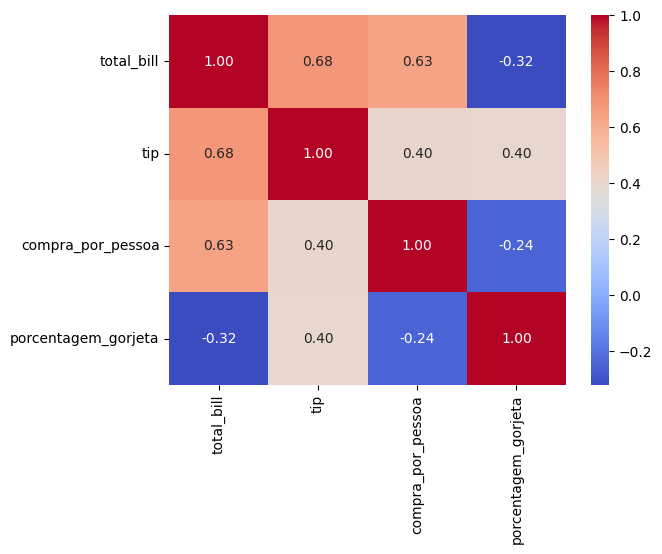

In [33]:
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()